<a href="https://colab.research.google.com/github/marcebm19/BOOTCAMP-1/blob/Rama-Practica/Trabajo_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np

In [8]:
# lee el archivo con el conjunto de datos de delitos informaticos y lo guarda en un DataFrame
df_delitos_informaticos = pd.read_csv('/content/drive/MyDrive/TRABAJO FINAL/Delitos_Informaticos_V1_20250228.csv')
df_delitos_informaticos = pd.DataFrame(df_delitos_informaticos)
# Encabezado del DataSet
df_delitos_informaticos.head()

,CRIMINALIDAD,ES_ARCHIVO,ES_PRECLUSIÓN,ESTADO,ETAPA_CASO,LEY,PAÍS_HECHO,DEPARTAMENTO_HECHO,MUNICIPIO_HECHO,SECCIONAL,AÑO_HECHOS,AÑO_ENTRADA,AÑO_DENUNCIA,DELITO,GRUPO_DELITO,CONSUMADO,TOTAL_PROCESOS
0,NO,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Santander,FLORIDABLANCA,DIRECCIÓN SECCIONAL DE SANTANDER,2020,2020,2020,VIOLACION DE DATOS PERSONALES ART 269F LEY 127...,DELITOS INFORMATICOS,NO APLICA,50
1,NO,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,"BOGOTÁ, D. C.","BOGOTÁ, D.C.",DIRECCIÓN SECCIONAL DE BOGOTÁ,2023,2023,2023,VIOLACION DE DATOS PERSONALES ART 269F LEY 127...,DELITOS INFORMATICOS,NO APLICA,114
2,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Antioquia,ITAGUI,DIRECCIÓN SECCIONAL DE MEDELLÍN,2021,2021,2021,ACCESO ABUSIVO A UN SISTEMA INFORMATICO ART 26...,DELITOS INFORMATICOS,NO APLICA,31
3,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Antioquia,ITAGUI,DIRECCIÓN SECCIONAL DE MEDELLÍN,2022,2022,2022,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,DELITOS INFORMATICOS,NO APLICA,153
4,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Valle del Cauca,CALI,DIRECCIÓN SECCIONAL DE CALI,2021,2021,2021,TRANSFERENCIA NO CONSENTIDA DE ACTIVOS VALIEND...,DELITOS INFORMATICOS,NO APLICA,61


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
df_delitos_informaticos.describe()

,AÑO_HECHOS,AÑO_ENTRADA,TOTAL_PROCESOS
count,55417.000000,55417.000000,55417.000000
mean,2019.629789,2020.011838,8.006298
std,3.799876,3.715237,88.801123
min,2010.000000,2010.000000,1.000000
25%,2017.000000,2018.000000,1.000000
50%,2021.000000,2021.000000,1.000000
75%,2023.000000,2023.000000,2.000000
max,2025.000000,2025.000000,8715.000000


In [11]:
df_delitos_informaticos.shape

(55417, 17)

In [12]:
df_delitos_informaticos.columns

Index(['CRIMINALIDAD', 'ES_ARCHIVO', 'ES_PRECLUSIÓN', 'ESTADO', 'ETAPA_CASO',
       'LEY', 'PAÍS_HECHO', 'DEPARTAMENTO_HECHO', 'MUNICIPIO_HECHO',
       'SECCIONAL', 'AÑO_HECHOS', 'AÑO_ENTRADA', 'AÑO_DENUNCIA', 'DELITO',
       'GRUPO_DELITO', 'CONSUMADO', 'TOTAL_PROCESOS'],
      dtype='object')

**Limpieza y transformacion de datos**

In [13]:
df_delitos_informaticos.isnull().sum()

,0
CRIMINALIDAD,0
ES_ARCHIVO,0
ES_PRECLUSIÓN,0
ESTADO,0
ETAPA_CASO,0
LEY,0
PAÍS_HECHO,0
DEPARTAMENTO_HECHO,0
MUNICIPIO_HECHO,0
SECCIONAL,0


**LIMPIEZA DE DATOS**

In [14]:
# Tipos de campos y dimensión del DataSet
df_delitos_informaticos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55417 entries, 0 to 55416
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CRIMINALIDAD        55417 non-null  object
 1   ES_ARCHIVO          55417 non-null  object
 2   ES_PRECLUSIÓN       55417 non-null  object
 3   ESTADO              55417 non-null  object
 4   ETAPA_CASO          55417 non-null  object
 5   LEY                 55417 non-null  object
 6   PAÍS_HECHO          55417 non-null  object
 7   DEPARTAMENTO_HECHO  55417 non-null  object
 8   MUNICIPIO_HECHO     55417 non-null  object
 9   SECCIONAL           55417 non-null  object
 10  AÑO_HECHOS          55417 non-null  int64 
 11  AÑO_ENTRADA         55417 non-null  int64 
 12  AÑO_DENUNCIA        55417 non-null  object
 13  DELITO              55417 non-null  object
 14  GRUPO_DELITO        55417 non-null  object
 15  CONSUMADO           55417 non-null  object
 16  TOTAL_PROCESOS      55

In [15]:
## Identificacion de registros duplicados donde coinciden en todos los campos
DF_duplicados = df_delitos_informaticos.duplicated()
print(f"El numero de registros duplicados es de: {DF_duplicados.sum()}")

El numero de registros duplicados es de: 0


In [16]:
pd.unique(df_delitos_informaticos['CRIMINALIDAD'])

array(['NO', 'SI'], dtype=object)

In [17]:
pd.unique(df_delitos_informaticos['ES_ARCHIVO'])

array(['SI', 'NO'], dtype=object)

In [18]:
pd.unique(df_delitos_informaticos["ES_PRECLUSIÓN"])

array(['NO', 'SI'], dtype=object)

In [19]:
pd.unique(df_delitos_informaticos['ESTADO'])

array(['INACTIVO', 'ACTIVO'], dtype=object)

In [20]:
pd.unique(df_delitos_informaticos['ETAPA_CASO'])

array(['INDAGACIÓN', 'EJECUCIÓN DE PENAS', 'INVESTIGACIÓN',
       'TERMINACIÓN ANTICIPADA', 'JUICIO'], dtype=object)

In [21]:
pd.unique(df_delitos_informaticos['LEY'])

array(['Ley 906', 'Ley 1098', 'Jurisdicción Menores'], dtype=object)

In [22]:
pd.unique(df_delitos_informaticos['PAÍS_HECHO'])

array(['Colombia', 'SIN DATO'], dtype=object)

In [23]:
df_delitos_informaticos.groupby("PAÍS_HECHO").size()

,0
PAÍS_HECHO,
Colombia,55406
SIN DATO,11


In [24]:
#Se decide reemplazar "Sin dato" por nulo.
df_delitos_informaticos[df_delitos_informaticos['PAÍS_HECHO'] == 'SIN DATO']

,CRIMINALIDAD,ES_ARCHIVO,ES_PRECLUSIÓN,ESTADO,ETAPA_CASO,LEY,PAÍS_HECHO,DEPARTAMENTO_HECHO,MUNICIPIO_HECHO,SECCIONAL,AÑO_HECHOS,AÑO_ENTRADA,AÑO_DENUNCIA,DELITO,GRUPO_DELITO,CONSUMADO,TOTAL_PROCESOS
5032,NO,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,SIN DATO,SIN DATO,SIN DATO,DIRECCIÓN SECCIONAL DE ATLÁNTICO,2024,2024,SIN DATO,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,DELITOS INFORMATICOS,NO APLICA,2
9513,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,SIN DATO,SIN DATO,SIN DATO,DIRECCIÓN SECCIONAL DE ATLÁNTICO,2024,2024,SIN DATO,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,DELITOS INFORMATICOS,NO APLICA,2
27789,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,SIN DATO,SIN DATO,SIN DATO,DIRECCIÓN SECCIONAL DE BOGOTÁ,2018,2018,2018,ACCESO ABUSIVO A UN SISTEMA INFORMATICO ART 26...,DELITOS INFORMATICOS,NO APLICA,3
32084,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,SIN DATO,SIN DATO,SIN DATO,DIRECCIÓN SECCIONAL DE MEDELLÍN,2024,2024,SIN DATO,ACCESO ABUSIVO A UN SISTEMA INFORMATICO ART 26...,DELITOS INFORMATICOS,NO APLICA,2
33884,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,SIN DATO,SIN DATO,SIN DATO,DIRECCIÓN SECCIONAL DE SUCRE,2024,2024,SIN DATO,MANIPULACION DE EQUIPOS MOVILES TERMINALES. AR...,DELITOS INFORMATICOS,NO APLICA,1
34020,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,SIN DATO,SIN DATO,SIN DATO,DIRECCIÓN SECCIONAL DE MEDELLÍN,2024,2024,SIN DATO,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,DELITOS INFORMATICOS,NO APLICA,2
38632,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,SIN DATO,SIN DATO,SIN DATO,DIRECCIÓN SECCIONAL DE MEDELLÍN,2024,2024,SIN DATO,SUPLANTACION DE SITIOS WEB PARA CAPTURAR DATOS...,DELITOS INFORMATICOS,NO APLICA,1
41291,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,SIN DATO,SIN DATO,SIN DATO,DIRECCIÓN SECCIONAL DE MAGDALENA MEDIO,2024,2024,SIN DATO,ACCESO ABUSIVO A UN SISTEMA INFORMATICO ART 26...,DELITOS INFORMATICOS,NO APLICA,1
46181,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,SIN DATO,SIN DATO,SIN DATO,DIRECCIÓN SECCIONAL DE BOGOTÁ,2018,2018,2018,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,DELITOS INFORMATICOS,NO APLICA,1
51016,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,SIN DATO,SIN DATO,SIN DATO,DIRECCIÓN SECCIONAL DE ATLÁNTICO,2024,2024,SIN DATO,DE LA PROTECCION DE LA INFORMACION Y DE LOS DATOS,DELITOS INFORMATICOS,NO APLICA,2


In [25]:
df_delitos_informaticos_corregido = df_delitos_informaticos.replace('SIN DATO', np.nan) #revisar
df_delitos_informaticos_corregido

,CRIMINALIDAD,ES_ARCHIVO,ES_PRECLUSIÓN,ESTADO,ETAPA_CASO,LEY,PAÍS_HECHO,DEPARTAMENTO_HECHO,MUNICIPIO_HECHO,SECCIONAL,AÑO_HECHOS,AÑO_ENTRADA,AÑO_DENUNCIA,DELITO,GRUPO_DELITO,CONSUMADO,TOTAL_PROCESOS
0,NO,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Santander,FLORIDABLANCA,DIRECCIÓN SECCIONAL DE SANTANDER,2020,2020,2020,VIOLACION DE DATOS PERSONALES ART 269F LEY 127...,DELITOS INFORMATICOS,NO APLICA,50
1,NO,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,"BOGOTÁ, D. C.","BOGOTÁ, D.C.",DIRECCIÓN SECCIONAL DE BOGOTÁ,2023,2023,2023,VIOLACION DE DATOS PERSONALES ART 269F LEY 127...,DELITOS INFORMATICOS,NO APLICA,114
2,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Antioquia,ITAGUI,DIRECCIÓN SECCIONAL DE MEDELLÍN,2021,2021,2021,ACCESO ABUSIVO A UN SISTEMA INFORMATICO ART 26...,DELITOS INFORMATICOS,NO APLICA,31
3,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Antioquia,ITAGUI,DIRECCIÓN SECCIONAL DE MEDELLÍN,2022,2022,2022,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,DELITOS INFORMATICOS,NO APLICA,153
4,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Valle del Cauca,CALI,DIRECCIÓN SECCIONAL DE CALI,2021,2021,2021,TRANSFERENCIA NO CONSENTIDA DE ACTIVOS VALIEND...,DELITOS INFORMATICOS,NO APLICA,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55412,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Sucre,SINCELEJO,DIRECCIÓN SECCIONAL DE SUCRE,2022,2022,2022,SUPLANTACION DE SITIOS WEB PARA CAPTURAR DATOS...,DELITOS INFORMATICOS,NO APLICA,1
55413,NO,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Caldas,LA DORADA,DIRECCIÓN SECCIONAL DE CALDAS,2021,2021,2021,VIOLACION DE DATOS PERSONALES ART 269F LEY 127...,DELITOS INFORMATICOS,NO APLICA,1
55414,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Sucre,SINCELEJO,DIRECCIÓN SECCIONAL DE SUCRE,2016,2016,2016,INTERCEPTACION DE DATOS INFORMATICOS ART 269C ...,DELITOS INFORMATICOS,NO APLICA,1
55415,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,Colombia,Santander,GÜEPSA,DIRECCIÓN SECCIONAL DE SANTANDER,2018,2018,2018,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,DELITOS INFORMATICOS,NO APLICA,1


In [26]:
df_delitos_informaticos_corregido[df_delitos_informaticos_corregido['PAÍS_HECHO'].isna()]

,CRIMINALIDAD,ES_ARCHIVO,ES_PRECLUSIÓN,ESTADO,ETAPA_CASO,LEY,PAÍS_HECHO,DEPARTAMENTO_HECHO,MUNICIPIO_HECHO,SECCIONAL,AÑO_HECHOS,AÑO_ENTRADA,AÑO_DENUNCIA,DELITO,GRUPO_DELITO,CONSUMADO,TOTAL_PROCESOS
5032,NO,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,NaN,NaN,NaN,DIRECCIÓN SECCIONAL DE ATLÁNTICO,2024,2024,NaN,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,DELITOS INFORMATICOS,NO APLICA,2
9513,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,NaN,NaN,NaN,DIRECCIÓN SECCIONAL DE ATLÁNTICO,2024,2024,NaN,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,DELITOS INFORMATICOS,NO APLICA,2
27789,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,NaN,NaN,NaN,DIRECCIÓN SECCIONAL DE BOGOTÁ,2018,2018,2018,ACCESO ABUSIVO A UN SISTEMA INFORMATICO ART 26...,DELITOS INFORMATICOS,NO APLICA,3
32084,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,NaN,NaN,NaN,DIRECCIÓN SECCIONAL DE MEDELLÍN,2024,2024,NaN,ACCESO ABUSIVO A UN SISTEMA INFORMATICO ART 26...,DELITOS INFORMATICOS,NO APLICA,2
33884,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,NaN,NaN,NaN,DIRECCIÓN SECCIONAL DE SUCRE,2024,2024,NaN,MANIPULACION DE EQUIPOS MOVILES TERMINALES. AR...,DELITOS INFORMATICOS,NO APLICA,1
34020,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,NaN,NaN,NaN,DIRECCIÓN SECCIONAL DE MEDELLÍN,2024,2024,NaN,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,DELITOS INFORMATICOS,NO APLICA,2
38632,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,NaN,NaN,NaN,DIRECCIÓN SECCIONAL DE MEDELLÍN,2024,2024,NaN,SUPLANTACION DE SITIOS WEB PARA CAPTURAR DATOS...,DELITOS INFORMATICOS,NO APLICA,1
41291,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,NaN,NaN,NaN,DIRECCIÓN SECCIONAL DE MAGDALENA MEDIO,2024,2024,NaN,ACCESO ABUSIVO A UN SISTEMA INFORMATICO ART 26...,DELITOS INFORMATICOS,NO APLICA,1
46181,SI,SI,NO,INACTIVO,INDAGACIÓN,Ley 906,NaN,NaN,NaN,DIRECCIÓN SECCIONAL DE BOGOTÁ,2018,2018,2018,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,DELITOS INFORMATICOS,NO APLICA,1
51016,SI,NO,NO,ACTIVO,INDAGACIÓN,Ley 906,NaN,NaN,NaN,DIRECCIÓN SECCIONAL DE ATLÁNTICO,2024,2024,NaN,DE LA PROTECCION DE LA INFORMACION Y DE LOS DATOS,DELITOS INFORMATICOS,NO APLICA,2


In [27]:
pd.unique(df_delitos_informaticos_corregido['DEPARTAMENTO_HECHO'])

array(['Santander', 'BOGOTÁ, D. C.', 'Antioquia', 'Valle del Cauca',
       'Quindío', 'Nariño', 'Huila', 'Cundinamarca', 'Norte de Santander',
       'Caldas', 'Meta', 'Boyaca', 'Córdoba', 'Cesar', 'Cauca',
       'Magdalena', 'Tolima', 'Risaralda', 'Bolívar', 'Sucre', 'Arauca',
       'Atlántico', 'La Guajira',
       'Archipiélago de San Andrés, Providencia y Santa Catalina',
       'Caquetá', 'Putumayo', 'Chocó', 'Casanare', 'Guaviare', 'Amazonas',
       'Guainía', 'Vichada', 'Vaupés', nan], dtype=object)

In [28]:
pd.unique(df_delitos_informaticos['MUNICIPIO_HECHO'])

array(['FLORIDABLANCA', 'BOGOTÁ, D.C.', 'ITAGUI', ..., 'CUÍTIVA',
       'RÍO IRO', 'UBATÉ'], dtype=object)

In [29]:
Lista_Municipios = df_delitos_informaticos_corregido.MUNICIPIO_HECHO.unique().tolist()
print (Lista_Municipios, sep= '\n')

['FLORIDABLANCA', 'BOGOTÁ, D.C.', 'ITAGUI', 'CALI', 'ARMENIA', 'PASTO', 'ENVIGADO', 'NEIVA', 'DON MATÍAS', 'GIRARDOT', 'CÚCUTA', 'FUSAGASUGÁ', 'MANIZALES', 'TOLEDO', 'VILLAVICENCIO', 'TUNJA', 'GIGANTE', 'LORICA', 'VALLEDUPAR', 'SASAIMA', 'MOSQUERA', 'CAUCASIA', 'SANTANDER DE QUILICHAO', 'SITIONUEVO', 'RIONEGRO', 'SAN GIL', 'LÉRIDA', 'BUENOS AIRES', 'CIÉNAGA DE ORO', 'SANTA ROSA DE CABAL', 'RIVERA', 'MEDELLÍN', 'JARDÍN', 'IPIALES', 'DUITAMA', 'CUMARAL', 'MARIQUITA', 'SANTA CATALINA', 'MARÍA LA BAJA', 'EL COPEY', 'LA MERCED', 'CHALÁN', 'GUASCA', 'ZIPAQUIRÁ', 'TAME', 'AGUACHICA', 'BARRANQUILLA', 'LA PLATA', 'ROLDANILLO', 'PUERTO GAITÁN', 'MAICAO', 'FUNZA', 'PUERTO TEJADA', 'YUMBO', 'PACHO', 'BUCARAMANGA', 'FUNDACIÓN', 'ARACATACA', 'TRUJILLO', 'BARRANCABERMEJA', 'SAN PELAYO', 'SOACHA', 'CALARCA', 'CIRCASIA', 'MONTERÍA', 'SAN ANDRÉS', 'TIERRALTA', 'GRANADA', 'HERRÁN', 'MADRID', 'LOS SANTOS', 'LA ARGENTINA', 'FLORENCIA', 'GIRÓN', 'SUCRE', 'PUERTO COLOMBIA', 'CHÍA', 'CHAPARRAL', 'CARTAGENA', 

In [30]:
Lista_Municipios = df_delitos_informaticos_corregido.MUNICIPIO_HECHO.unique().tolist()
for municipio in Lista_Municipios:
    print(municipio)

FLORIDABLANCA
BOGOTÁ, D.C.
ITAGUI
CALI
ARMENIA
PASTO
ENVIGADO
NEIVA
DON MATÍAS
GIRARDOT
CÚCUTA
FUSAGASUGÁ
MANIZALES
TOLEDO
VILLAVICENCIO
TUNJA
GIGANTE
LORICA
VALLEDUPAR
SASAIMA
MOSQUERA
CAUCASIA
SANTANDER DE QUILICHAO
SITIONUEVO
RIONEGRO
SAN GIL
LÉRIDA
BUENOS AIRES
CIÉNAGA DE ORO
SANTA ROSA DE CABAL
RIVERA
MEDELLÍN
JARDÍN
IPIALES
DUITAMA
CUMARAL
MARIQUITA
SANTA CATALINA
MARÍA LA BAJA
EL COPEY
LA MERCED
CHALÁN
GUASCA
ZIPAQUIRÁ
TAME
AGUACHICA
BARRANQUILLA
LA PLATA
ROLDANILLO
PUERTO GAITÁN
MAICAO
FUNZA
PUERTO TEJADA
YUMBO
PACHO
BUCARAMANGA
FUNDACIÓN
ARACATACA
TRUJILLO
BARRANCABERMEJA
SAN PELAYO
SOACHA
CALARCA
CIRCASIA
MONTERÍA
SAN ANDRÉS
TIERRALTA
GRANADA
HERRÁN
MADRID
LOS SANTOS
LA ARGENTINA
FLORENCIA
GIRÓN
SUCRE
PUERTO COLOMBIA
CHÍA
CHAPARRAL
CARTAGENA
URUMITA
PIEDECUESTA
HONDA
PALMAR DE VARELA
PAIPA
LA UNIÓN
MIRANDA
CASTILLA LA NUEVA
SANTA MARTA
DOSQUEBRADAS
SABANETA
PIVIJAY
GALAPA
CURUMANÍ
TORO
BUGALAGRANDE
LA CALERA
BUENAVENTURA
COROZAL
ARIGUANÍ
SABOYÁ
PALMIRA
SOGAMOSO
RIOHACHA
VILLA

In [31]:
delitos_municipio = df_delitos_informaticos_corregido.groupby('MUNICIPIO_HECHO').size().sort_values(ascending=False)
delitos_municipio.head(20)

,0
MUNICIPIO_HECHO,
"BOGOTÁ, D.C.",3481
MEDELLÍN,1860
CALI,1347
BARRANQUILLA,1206
IBAGUÉ,787
CARTAGENA,752
BUCARAMANGA,710
CÚCUTA,678
VILLAVICENCIO,657


In [32]:
pd.unique(df_delitos_informaticos_corregido['SECCIONAL'])

array(['DIRECCIÓN SECCIONAL DE SANTANDER',
       'DIRECCIÓN SECCIONAL DE BOGOTÁ', 'DIRECCIÓN SECCIONAL DE MEDELLÍN',
       'DIRECCIÓN SECCIONAL DE CALI', 'DIRECCIÓN SECCIONAL DE QUINDÍO',
       'DIRECCIÓN SECCIONAL DE NARIÑO', 'DIRECCIÓN SECCIONAL DE HUILA',
       'DIRECCIÓN SECCIONAL DE ANTIOQUIA',
       'DIRECCIÓN SECCIONAL DE CUNDINAMARCA',
       'DIRECCIÓN SECCIONAL DE NORTE DE SANTANDER',
       'DIRECCIÓN SECCIONAL DE CALDAS', 'DIRECCIÓN SECCIONAL DE META',
       'DIRECCIÓN SECCIONAL DE TOLIMA', 'DIRECCIÓN SECCIONAL DE CÓRDOBA',
       'DIRECCIÓN SECCIONAL DE CESAR', 'DIRECCIÓN SECCIONAL DE CAUCA',
       'DIRECCIÓN SECCIONAL DE ATLÁNTICO',
       'DIRECCIÓN SECCIONAL DE RISARALDA',
       'DIRECCION ESPECIALIZADA CONTRA LOS DELITOS INFORMATICOS',
       'DIRECCIÓN SECCIONAL DE BOYACÁ', 'DIRECCIÓN SECCIONAL DE BOLÍVAR',
       'DIRECCIÓN SECCIONAL DE SUCRE', 'DIRECCIÓN SECCIONAL DE ARAUCA',
       'DIRECCIÓN SECCIONAL DE MAGDALENA MEDIO',
       'DIRECCIÓN SECCIONAL DE VAL

In [33]:
delitos_informaticos = df_delitos_informaticos.groupby('DEPARTAMENTO_HECHO').size().sort_values(ascending=False)
delitos_informaticos

,0
DEPARTAMENTO_HECHO,
Antioquia,7571
Cundinamarca,5777
Valle del Cauca,4470
"BOGOTÁ, D. C.",3481
Santander,3078
Tolima,2612
Atlántico,2480
Boyaca,2335
Huila,1824


In [34]:
sorted(pd.unique(df_delitos_informaticos_corregido['AÑO_HECHOS']))

[2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024,
 2025]

In [35]:
sorted(pd.unique(df_delitos_informaticos_corregido['AÑO_ENTRADA']))

[2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024,
 2025]

In [36]:
# AÑO_DENUNCIA maneja columnas con datos 'SIN DATO'
pd.unique(df_delitos_informaticos.AÑO_DENUNCIA)

array(['2020', '2023', '2021', '2022', '2012', '2019', '2014', '2024',
       '2013', '2017', '2016', '2015', '2018', '2010', '2025', '2011',
       'SIN DATO'], dtype=object)

In [37]:
# Total de valores encontrados 'SIN DATO'
df_delitos_informaticos['AÑO_DENUNCIA'].value_counts()

,count
AÑO_DENUNCIA,
2024,7854
2023,7262
2022,7060
2021,6057
2020,5162
2019,3701
2018,3592
2017,2638
2016,2173


In [38]:
(pd.unique(df_delitos_informaticos_corregido['AÑO_DENUNCIA']))

array(['2020', '2023', '2021', '2022', '2012', '2019', '2014', '2024',
       '2013', '2017', '2016', '2015', '2018', '2010', '2025', '2011',
       nan], dtype=object)

In [39]:
pd.unique(df_delitos_informaticos['GRUPO_DELITO'])

array(['DELITOS INFORMATICOS'], dtype=object)

In [40]:
# Validar conversión
df_delitos_informaticos_corregido['AÑO_DENUNCIA'].isna().sum()

9

In [41]:
type(df_delitos_informaticos_corregido['AÑO_DENUNCIA'][0])

str

In [42]:
# Antes de convertir AÑO_DENUNCIA en numerico, revisamos que es de tipo str.
df_delitos_informaticos_corregido['AÑO_DENUNCIA'] = pd.to_numeric(df_delitos_informaticos_corregido['AÑO_DENUNCIA'], errors='coerce')

In [43]:
# Validar tipo de dato
type(df_delitos_informaticos_corregido['AÑO_DENUNCIA'][0])

numpy.float64

In [44]:
# Convertir a enteros (int64), manteniendo NaN
df_delitos_informaticos_corregido['AÑO_DENUNCIA'] = df_delitos_informaticos_corregido['AÑO_DENUNCIA'].astype('Int64')

Analisis de Correlación

In [45]:
# Matriz de correlación entre los años
correlacion = df_delitos_informaticos_corregido[['AÑO_HECHOS', 'AÑO_ENTRADA', 'AÑO_DENUNCIA']].corr()
print(correlacion)

              AÑO_HECHOS  AÑO_ENTRADA  AÑO_DENUNCIA
AÑO_HECHOS      1.000000     0.959416      0.970606
AÑO_ENTRADA     0.959416     1.000000      0.988030
AÑO_DENUNCIA    0.970606     0.988030      1.000000


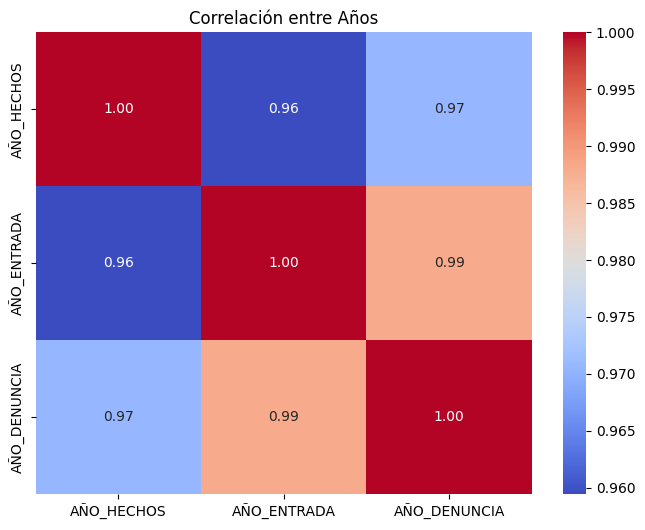

In [46]:
# Visualizar la matriz de correlación mediante un mapa de calor
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación entre Años')
plt.show()

Al analizar la correlación entre 'AÑO_HECHOS', 'AÑO_ENTRADA' y 'AÑO_DENUNCIA'. El análisis muestra una fuerte correlación positiva entre estas tres variables.

Tendencia de delitos informáticos por año.

In [67]:
# Agrupar por año y contar el total de procesos
tendencias_por_año = df_delitos_informaticos_corregido.groupby('AÑO_HECHOS')['TOTAL_PROCESOS'].sum().reset_index()

# Ver el resultado
print(tendencias_por_año)




    AÑO_HECHOS  TOTAL_PROCESOS
0         2010            5465
1         2011            5990
2         2012            6757
3         2013            9225
4         2014            9338
5         2015           10048
6         2016           11980
7         2017           15090
8         2018           22620
9         2019           24291
10        2020           41465
11        2021           48665
12        2022           67653
13        2023           73688
14        2024           86938
15        2025            4472


In [71]:
# Filtrar los datos para excluir el año 2025
# Se asigna df_delitos_informaticos_corregido a df_filtrado antes de filtrarlo
df_filtrado = df_delitos_informaticos_corregido[df_delitos_informaticos_corregido['AÑO_HECHOS'] != 2025]

# Agrupar por año y contar el total de procesos
tendencias_por_año = df_filtrado.groupby('AÑO_HECHOS')['TOTAL_PROCESOS'].sum().reset_index()

# Ver el resultado
print(tendencias_por_año)

    AÑO_HECHOS  TOTAL_PROCESOS
0         2010            5465
1         2011            5990
2         2012            6757
3         2013            9225
4         2014            9338
5         2015           10048
6         2016           11980
7         2017           15090
8         2018           22620
9         2019           24291
10        2020           41465
11        2021           48665
12        2022           67653
13        2023           73688
14        2024           86938


In [70]:
import plotly.express as px

# Crear gráfico interactivo
fig = px.line(tendencias_por_año,
               x='AÑO_HECHOS',
               y='TOTAL_PROCESOS',
               title='Tendencia de Delitos Informáticos por Año',
               labels={'AÑO_HECHOS': 'Año', 'TOTAL_PROCESOS': 'Número Total de Procesos'},
               markers=True)

# Personalizar el diseño y quitar la "k" del eje Y
fig.update_traces(line=dict(color='teal', width=2))
fig.update_layout(
    hovermode='x unified',
    template='plotly_dark',
    yaxis=dict(tickformat=',')  # Formato con comas para separar miles (ej: 10,000)
)

# Mostrar el gráfico
fig.show()

In [72]:
Delitos_año_hechos = df_delitos_informaticos_corregido.groupby(["DELITO","AÑO_HECHOS"]).size()
Delitos_año_hechos

DELITO                                                                                                                                 AÑO_HECHOS
ACCESO ABUSIVO A UN SISTEMA INFORMATICO ART 269A LEY 1273 DE 2009                                                                      2010          246
                                                                                                                                       2011          315
                                                                                                                                       2012          286
                                                                                                                                       2013          345
                                                                                                                                       2014          331
                                                                                                                                                    ... 
VIOLACION DE DATOS PERSONALES ART 269F LEY 1273 DE 2009, AGRAVADO POR UTILIZAR COMO INSTRUMENTO A UN TERCERO DE BUENA FE ART. 269H N7  2020           10
                                                                                                                                       2021            5
                                                                                                                                       2022           10
                                                                                                                                       2023           11
                                                                                                                                       2024            7
Length: 761, dtype: int64

In [73]:
df_delito4 = df_delitos_informaticos_corregido.loc[:, ['DELITO', 'AÑO_HECHOS']]
df_delito4

,DELITO,AÑO_HECHOS
0,VIOLACION DE DATOS PERSONALES ART 269F LEY 127...,2020
1,VIOLACION DE DATOS PERSONALES ART 269F LEY 127...,2023
2,ACCESO ABUSIVO A UN SISTEMA INFORMATICO ART 26...,2021
3,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,2022
4,TRANSFERENCIA NO CONSENTIDA DE ACTIVOS VALIEND...,2021
...,...,...
55412,SUPLANTACION DE SITIOS WEB PARA CAPTURAR DATOS...,2022
55413,VIOLACION DE DATOS PERSONALES ART 269F LEY 127...,2021
55414,INTERCEPTACION DE DATOS INFORMATICOS ART 269C ...,2016
55415,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ART...,2018


In [74]:
# Primero, vamos a limpiar la columna DELITO de las descripciones y artículos adicionales
df_delito4['DELITO'] = df_delito4['DELITO'].str.replace(r'(ART|LEY).*', '', regex=True)
df_delito4

,DELITO,AÑO_HECHOS
0,VIOLACION DE DATOS PERSONALES,2020
1,VIOLACION DE DATOS PERSONALES,2023
2,ACCESO ABUSIVO A UN SISTEMA INFORMATICO,2021
3,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES,2022
4,TRANSFERENCIA NO CONSENTIDA DE ACTIVOS VALIEND...,2021
...,...,...
55412,SUPLANTACION DE SITIOS WEB PARA CAPTURAR DATOS...,2022
55413,VIOLACION DE DATOS PERSONALES,2021
55414,INTERCEPTACION DE DATOS INFORMATICOS,2016
55415,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES,2018


In [75]:
pd.unique(df_delito4["DELITO"])

array(['VIOLACION DE DATOS PERSONALES ',
       'ACCESO ABUSIVO A UN SISTEMA INFORMATICO ',
       'HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES ',
       'TRANSFERENCIA NO CONSENTIDA DE ACTIVOS VALIENDOSE DE ALGUNA MANIPULACION INFORMATICA O ',
       'INTERCEPTACION DE DATOS INFORMATICOS, ',
       'SUPLANTACION DE SITIOS WEB PARA CAPTURAR DATOS PERSONALES ',
       'OBSTACULIZACION ILEGITIMA DEL SISTEMA INFORMATICO O RED DE TELECOMUNICACION ',
       'DAÑO INFORMATICO ',
       'MANIPULACION DE EQUIPOS MOVILES TERMINALES. ',
       'USO DE SOFTWARE MALICIOSO ',
       'DE LOS ATENTADOS INFORMATICOS Y OTRAS INFRACCIONES',
       'INTERCEPTACION DE DATOS INFORMATICOS ',
       'DE LOS ATENTADOS CONTRA LA CONFIDENCIALIDAD, LA INTEGRIDAD Y LA DISPONIBILIDAD DE LOS DATOS Y DE LOS SISTEMAS INFORMATICOS',
       'DE LA PROTECCION DE LA INFORMACION Y DE LOS DATOS'], dtype=object)

In [76]:
df_delito4['DELITO'] = df_delito4['DELITO'].str.strip().str.upper()
df_delito4


,DELITO,AÑO_HECHOS
0,VIOLACION DE DATOS PERSONALES,2020
1,VIOLACION DE DATOS PERSONALES,2023
2,ACCESO ABUSIVO A UN SISTEMA INFORMATICO,2021
3,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES,2022
4,TRANSFERENCIA NO CONSENTIDA DE ACTIVOS VALIEND...,2021
...,...,...
55412,SUPLANTACION DE SITIOS WEB PARA CAPTURAR DATOS...,2022
55413,VIOLACION DE DATOS PERSONALES,2021
55414,INTERCEPTACION DE DATOS INFORMATICOS,2016
55415,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES,2018


In [77]:
df_delito4.replace('INTERCEPTACION DE DATOS INFORMATICOS,','INTERCEPTACION DE DATOS INFORMATICOS',inplace=True)
df_delito4

,DELITO,AÑO_HECHOS
0,VIOLACION DE DATOS PERSONALES,2020
1,VIOLACION DE DATOS PERSONALES,2023
2,ACCESO ABUSIVO A UN SISTEMA INFORMATICO,2021
3,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES,2022
4,TRANSFERENCIA NO CONSENTIDA DE ACTIVOS VALIEND...,2021
...,...,...
55412,SUPLANTACION DE SITIOS WEB PARA CAPTURAR DATOS...,2022
55413,VIOLACION DE DATOS PERSONALES,2021
55414,INTERCEPTACION DE DATOS INFORMATICOS,2016
55415,HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES,2018


In [78]:
pd.unique(df_delito4["DELITO"])

array(['VIOLACION DE DATOS PERSONALES',
       'ACCESO ABUSIVO A UN SISTEMA INFORMATICO',
       'HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES',
       'TRANSFERENCIA NO CONSENTIDA DE ACTIVOS VALIENDOSE DE ALGUNA MANIPULACION INFORMATICA O',
       'INTERCEPTACION DE DATOS INFORMATICOS',
       'SUPLANTACION DE SITIOS WEB PARA CAPTURAR DATOS PERSONALES',
       'OBSTACULIZACION ILEGITIMA DEL SISTEMA INFORMATICO O RED DE TELECOMUNICACION',
       'DAÑO INFORMATICO', 'MANIPULACION DE EQUIPOS MOVILES TERMINALES.',
       'USO DE SOFTWARE MALICIOSO',
       'DE LOS ATENTADOS INFORMATICOS Y OTRAS INFRACCIONES',
       'DE LOS ATENTADOS CONTRA LA CONFIDENCIALIDAD, LA INTEGRIDAD Y LA DISPONIBILIDAD DE LOS DATOS Y DE LOS SISTEMAS INFORMATICOS',
       'DE LA PROTECCION DE LA INFORMACION Y DE LOS DATOS'], dtype=object)

                                      DELITO  AÑO_HECHOS  Cantidad de Delitos
0    ACCESO ABUSIVO A UN SISTEMA INFORMATICO        2010                  327
1    ACCESO ABUSIVO A UN SISTEMA INFORMATICO        2011                  383
2    ACCESO ABUSIVO A UN SISTEMA INFORMATICO        2012                  345
3    ACCESO ABUSIVO A UN SISTEMA INFORMATICO        2013                  402
4    ACCESO ABUSIVO A UN SISTEMA INFORMATICO        2014                  410
..                                       ...         ...                  ...
190            VIOLACION DE DATOS PERSONALES        2021                 1259
191            VIOLACION DE DATOS PERSONALES        2022                 1417
192            VIOLACION DE DATOS PERSONALES        2023                 1354
193            VIOLACION DE DATOS PERSONALES        2024                 1248
194            VIOLACION DE DATOS PERSONALES        2025                  179

[195 rows x 3 columns]


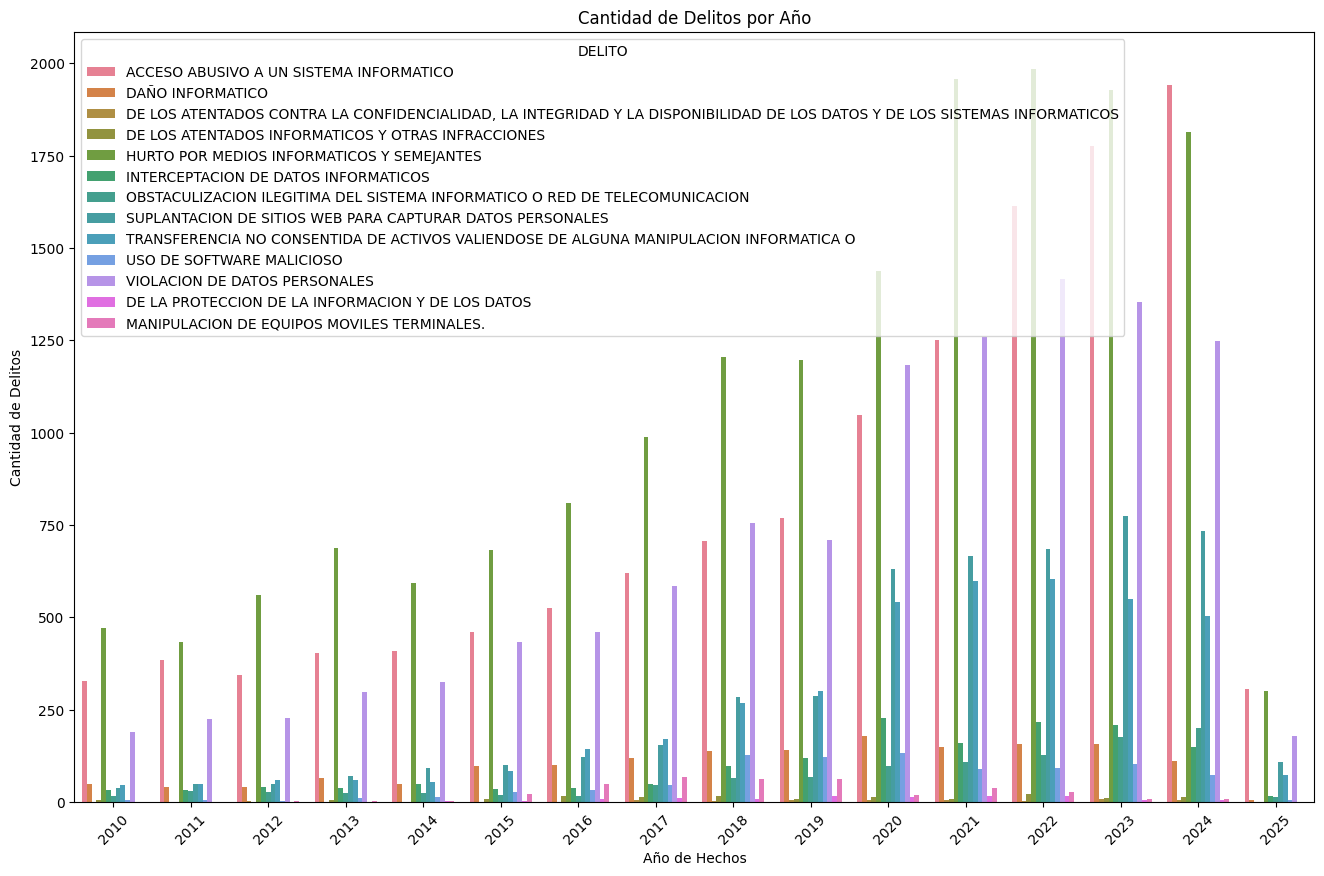

In [79]:
# Ahora, vamos a agrupar los datos por 'DELITO' y 'AÑO_HECHOS', y contar cuántos delitos ocurrieron en cada combinación
df_delito_unificado = df_delito4.groupby(['DELITO', 'AÑO_HECHOS']).size().reset_index(name='Cantidad de Delitos')

# Ver el resultado unificado
print(df_delito_unificado)

# Si quieres graficar los resultados (por ejemplo, delitos por año)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))
sns.barplot(x='AÑO_HECHOS', y='Cantidad de Delitos', hue='DELITO', data=df_delito_unificado)

plt.title('Cantidad de Delitos por Año')
plt.xlabel('Año de Hechos')
plt.ylabel('Cantidad de Delitos')
plt.xticks(rotation=45)
plt.show()

In [80]:
df_delito4.groupby("DELITO").size().sort_values(ascending=False)


,0
DELITO,
HURTO POR MEDIOS INFORMATICOS Y SEMEJANTES,17050
ACCESO ABUSIVO A UN SISTEMA INFORMATICO,12886
VIOLACION DE DATOS PERSONALES,10848
SUPLANTACION DE SITIOS WEB PARA CAPTURAR DATOS PERSONALES,4842
TRANSFERENCIA NO CONSENTIDA DE ACTIVOS VALIENDOSE DE ALGUNA MANIPULACION INFORMATICA O,4100
DAÑO INFORMATICO,1594
INTERCEPTACION DE DATOS INFORMATICOS,1504
OBSTACULIZACION ILEGITIMA DEL SISTEMA INFORMATICO O RED DE TELECOMUNICACION,1059
USO DE SOFTWARE MALICIOSO,884


In [61]:
type(df_delito4)

pandas.core.frame.DataFrame